# Statistical Learning and Data Analytics for Transportation Systems
## Problem Set 1 - Problems 3 and 4

**Name:** Mohd Zamin Quadri

In this notebook I solve Problem 3 and Problem 4. I kept the work split part by part,
in the same order as the questions, and after each output I write a few lines about
what the numbers actually mean.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
np.random.seed(0)
pd.set_option('display.float_format', lambda v: f'{v:.5f}')

---
# Problem 3 - Gasoline mileage (40 points)

The dataset has the highway mileage test results of 2005 DaimlerChrysler vehicles.
I have to predict the fuel economy `mpg` from six variables: `cid`, `rhp`, `etw`,
`cmp`, `axle` and `n_v`.

In [2]:
df3 = pd.read_csv('data_problem_3.csv')
df3.columns = df3.columns.str.strip()   # the header has some extra spaces, clean them
print('Shape:', df3.shape)
df3.head()

Shape: (21, 17)


,mfr,carline,car_truck,cid,rhp,trns,drv,od,etw,cmp,axle,n_v,a_c,hc,co,co2,mpg
0,20,300C/SRT-8,C,215,253,L5,4,2,4500,9.90000,3.07000,30.90000,Y,0.01100,0.09000,288,30.80000
1,20,CARAVAN 2WD,T,201,180,L4,F,2,4500,9.30000,2.49000,32.30000,Y,0.01400,0.11000,274,32.50000
2,20,CROSSFIRE ROADSTER,C,196,168,L5,R,2,3375,10.00000,3.27000,37.10000,Y,0.00100,0.02000,250,35.40000
3,20,DAKOTA PICKUP 2WD,T,226,210,L4,R,2,4500,9.20000,3.55000,29.60000,Y,0.01200,0.04000,316,28.10000
4,20,DAKOTA PICKUP 4WD,T,226,210,L4,4,2,5000,9.20000,3.55000,29.60000,Y,0.01100,0.05000,365,24.40000


## 3.1 Fitting the regression model

I fit an OLS model with the six predictors and `mpg` as the response.
`sm.add_constant` adds the intercept term to the design matrix.

In [3]:
predictors = ['cid', 'rhp', 'etw', 'cmp', 'axle', 'n_v']
y3 = df3['mpg']
X3 = sm.add_constant(df3[predictors])

model3 = sm.OLS(y3, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     19.53
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           4.66e-06
Time:                        16:46:12   Log-Likelihood:                -42.366
No. Observations:                  21   AIC:                             98.73
Df Residuals:                      14   BIC:                             106.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.9040     19.665      2.538      0.0

In [4]:
# write the fitted equation in a readable form
b = model3.params
eq = 'mpg_hat = {:.4f}'.format(b['const'])
for p in predictors:
    eq += ' {:+.4f}*{}'.format(b[p], p)
print(eq)

mpg_hat = 49.9040 -0.0104*cid -0.0012*rhp -0.0032*etw +0.2924*cmp -3.8554*axle +0.1897*n_v


The fit looks good. The R-squared is about 0.89, so these six variables together
explain roughly 89% of the variation in mileage. The two largest effects are the
axle ratio (strong negative coefficient) and the test weight - heavier vehicles
give lower mpg, which makes sense physically.

## 3.2 Estimating sigma squared and the standard errors

The error variance is estimated by the residual mean square,
sigma^2 = SS_Res / (n - p), where p counts all parameters including the intercept.
I also print the standard error of each coefficient (these come directly from the
fitted model).

In [5]:
n = df3.shape[0]
p = len(predictors) + 1          # 6 predictors + intercept
sigma2 = model3.mse_resid        # this is SS_Res / (n - p)

print('n (observations)      =', n)
print('p (parameters)        =', p)
print('residual d.o.f (n-p)  =', int(model3.df_resid))
print('sigma^2 (MS_Res)      = {:.4f}'.format(sigma2))
print('sigma (std. error)    = {:.4f}'.format(np.sqrt(sigma2)))
print()
print('Standard errors of the coefficients:')
print(model3.bse)

n (observations)      = 21
p (parameters)        = 7
residual d.o.f (n-p)  = 14
sigma^2 (MS_Res)      = 4.9653
sigma (std. error)    = 2.2283

Standard errors of the coefficients:
const   19.66524
cid      0.02338
rhp      0.01631
etw      0.00095
cmp      1.76474
axle     1.32865
n_v      0.27297
dtype: float64


## 3.3 Significance of regression (alpha = 0.05)

This test checks whether the model is useful overall:

H0: beta1 = beta2 = ... = beta6 = 0  (none of the variables help)
H1: at least one beta is not zero.

I compare the F statistic with the critical value F(0.05, df_model, df_resid).

In [6]:
F_stat   = model3.fvalue
F_pvalue = model3.f_pvalue
df_model = int(model3.df_model)
df_resid = int(model3.df_resid)
F_crit   = stats.f.ppf(0.95, df_model, df_resid)

print('F statistic             = {:.4f}'.format(F_stat))
print('degrees of freedom      = ({}, {})'.format(df_model, df_resid))
print('critical F(0.05)        = {:.4f}'.format(F_crit))
print('p-value                 = {:.3e}'.format(F_pvalue))

F statistic             = 19.5322
degrees of freedom      = (6, 14)
critical F(0.05)        = 2.8477
p-value                 = 4.664e-06


The F value is far above the critical F and the p-value is extremely small
(well below 0.05), so I reject H0. The regression is significant - the predictors
as a group really do explain the mileage.

## 3.4 t-test for each coefficient (alpha = 0.05)

Now I look at the variables one at a time. For each coefficient the hypotheses are
H0: beta_j = 0 against H1: beta_j != 0. A variable matters if |t| is above the
critical t, i.e. if its p-value is below 0.05.

In [7]:
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, model3.df_resid)

ttable = pd.DataFrame({
    'coef':    model3.params,
    'std_err': model3.bse,
    't_stat':  model3.tvalues,
    'p_value': model3.pvalues
})
ttable['significant'] = ttable['p_value'] < alpha
print('Critical t value = +/- {:.4f}'.format(t_crit))
ttable

Critical t value = +/- 2.1448


,coef,std_err,t_stat,p_value,significant
const,49.90400,19.66524,2.53768,0.02368,True
cid,-0.01045,0.02338,-0.44688,0.66180,False
rhp,-0.00120,0.01631,-0.07385,0.94217,False
etw,-0.00324,0.00095,-3.42146,0.00413,True
cmp,0.29243,1.76474,0.16571,0.87076,False
axle,-3.85536,1.32865,-2.90172,0.01160,True
n_v,0.18971,0.27297,0.69497,0.49845,False


Only `etw` and `axle` come out significant at 5% (their p-values are below 0.05).
The others - `cid`, `rhp`, `cmp` and `n_v` - are not significant individually, so
they don't add much once the other variables are already in the model. I think this
is mostly because the engine-size variables overlap a lot with each other.

## 3.5 99% confidence intervals for the coefficients

For a 99% interval I use alpha = 0.01. If an interval does not contain zero, that
coefficient is significant at the 1% level.

In [8]:
ci99 = model3.conf_int(alpha=0.01)
ci99.columns = ['lower (0.5%)', 'upper (99.5%)']
ci99

,lower (0.5%),upper (99.5%)
const,-8.63633,108.44433
cid,-0.08004,0.05915
rhp,-0.04975,0.04734
etw,-0.00605,-0.00042
cmp,-4.96091,5.54577
axle,-7.81054,0.09981
n_v,-0.62289,1.00231


The intervals are quite wide, which is expected with only 21 cars in the sample.
Most of them still contain zero, so this agrees with the t-tests - only a couple of
variables stand out clearly from zero.

## 3.6 Residual plots

I plot the residuals against the fitted values and against each predictor. If the
model is okay, the points should sit randomly around zero, without a clear curve or
a fan/funnel shape.

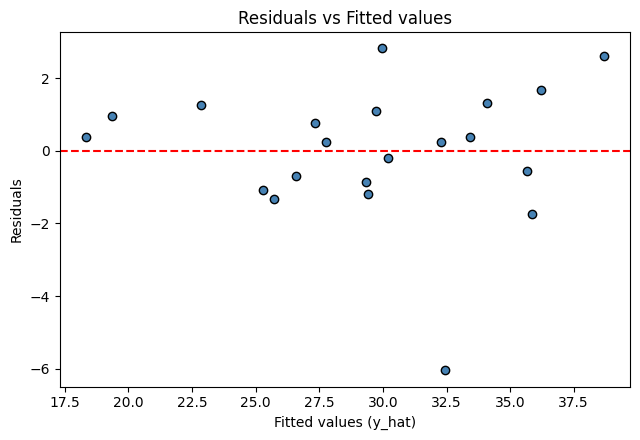

In [9]:
resid  = model3.resid
fitted = model3.fittedvalues

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(fitted, resid, color='steelblue', edgecolor='k')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted values (y_hat)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted values')
plt.tight_layout()
plt.show()

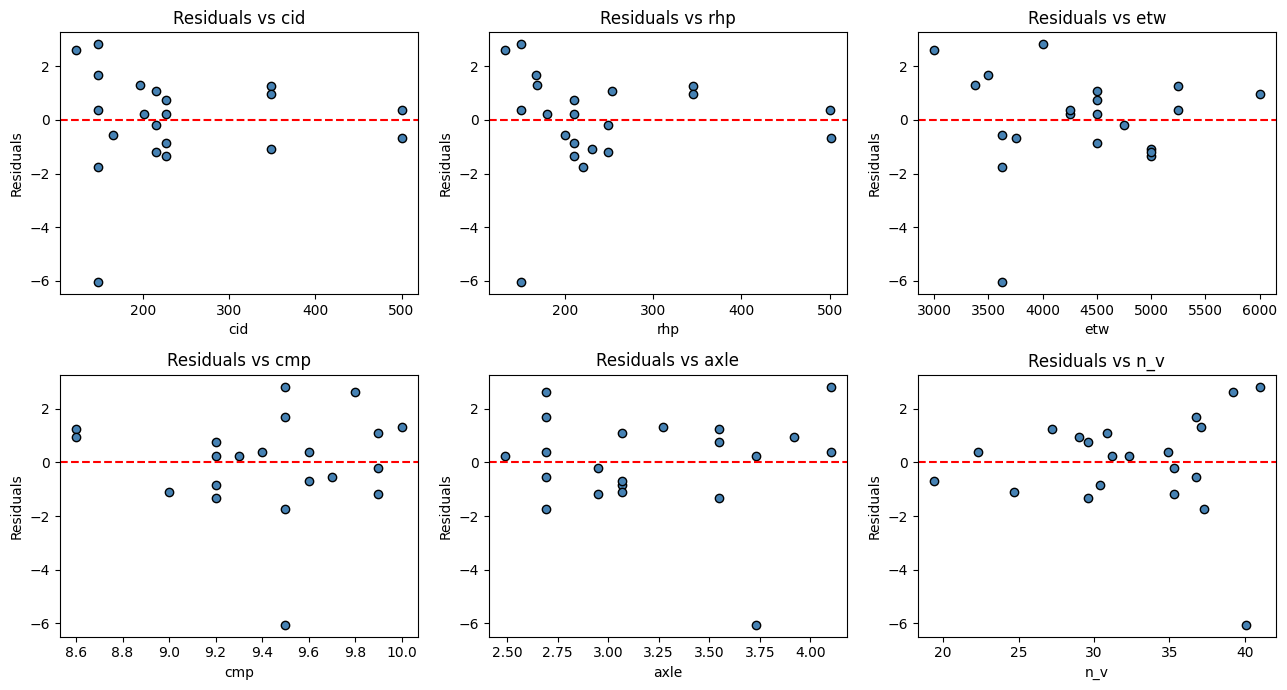

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), predictors):
    ax.scatter(df3[col], resid, color='steelblue', edgecolor='k')
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Residuals')
    ax.set_title('Residuals vs ' + col)
plt.tight_layout()
plt.show()

The residuals look reasonably random around zero and I can't see a strong curve
or a funnel, so the constant-variance and linearity assumptions seem fine. A few
points stick out a bit, but with such a small sample that is not surprising and
nothing looks seriously wrong.

## 3.7 Confidence and prediction limits for the mean response

For alpha = 0.05 I compute the 95% confidence interval of the mean response and the
95% prediction interval for a new observation. I sort the points by fitted value so
the bands are easier to read. The prediction band is wider because it also includes
the scatter of one new point.

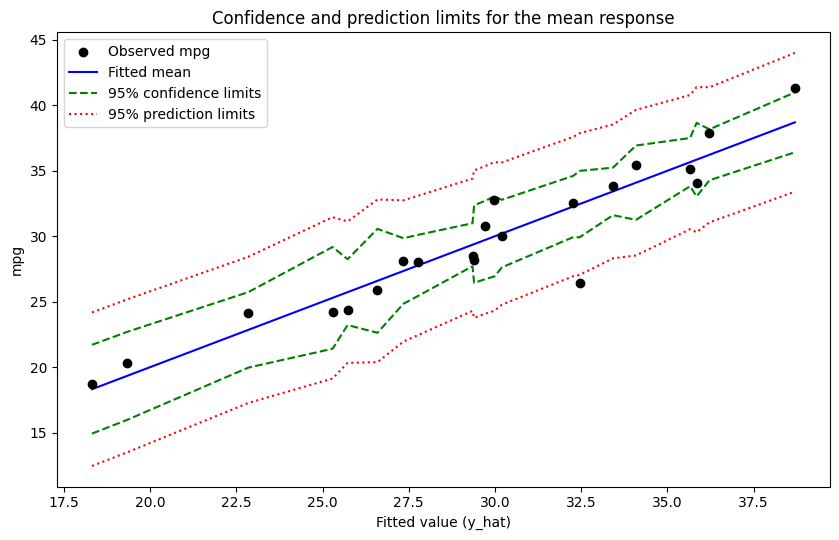

In [11]:
pred = model3.get_prediction(X3).summary_frame(alpha=0.05)
order = np.argsort(fitted.values)
xs = fitted.values[order]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(fitted, y3, color='black', zorder=5, label='Observed mpg')
ax.plot(xs, pred['mean'].values[order], color='blue', label='Fitted mean')
ax.plot(xs, pred['mean_ci_lower'].values[order], 'g--', label='95% confidence limits')
ax.plot(xs, pred['mean_ci_upper'].values[order], 'g--')
ax.plot(xs, pred['obs_ci_lower'].values[order], 'r:', label='95% prediction limits')
ax.plot(xs, pred['obs_ci_upper'].values[order], 'r:')
ax.set_xlabel('Fitted value (y_hat)')
ax.set_ylabel('mpg')
ax.set_title('Confidence and prediction limits for the mean response')
ax.legend()
plt.tight_layout()
plt.show()

As expected, the confidence limits (green) stay close to the fitted line and the
prediction limits (red) are clearly wider. Almost all the observed points fall
inside the prediction band, so the model's predictions look sensible for this data.

---
# Problem 4 - Freeway traffic speed (30 points)

This data comes from a two-lane part of the SR241-N freeway in California, recorded
every 5 minutes. The task is to predict the segment's average `speed` using the
other variables (`flow`, `occupancy`, `speed_down`, `flow_ratio`) and, if useful,
transformations of them.

In [12]:
df4 = pd.read_csv('data_problem_4.csv')
print('Shape:', df4.shape)
df4.describe()

Shape: (1816, 5)


,flow,occupancy,speed,speed_down,flow_ratio
count,1816.00000,1816.00000,1816.00000,1816.00000,1816.00000
mean,33.63656,3.61377,64.15325,64.19237,0.72963
std,20.10904,1.32588,2.18075,2.55626,0.18682
min,7.00000,1.90000,58.00000,55.80203,0.36842
25%,14.00000,2.30000,62.40000,62.36284,0.56000
50%,33.00000,3.50000,64.90000,64.56943,0.79744
75%,49.00000,4.70000,66.10000,66.13114,0.89091
max,91.00000,7.40000,67.80000,70.37070,1.00000


## 4.1 Looking at the relationship between every pair of variables

The pair plot shows each variable against every other one, and the correlation
heatmap gives the same idea as numbers.

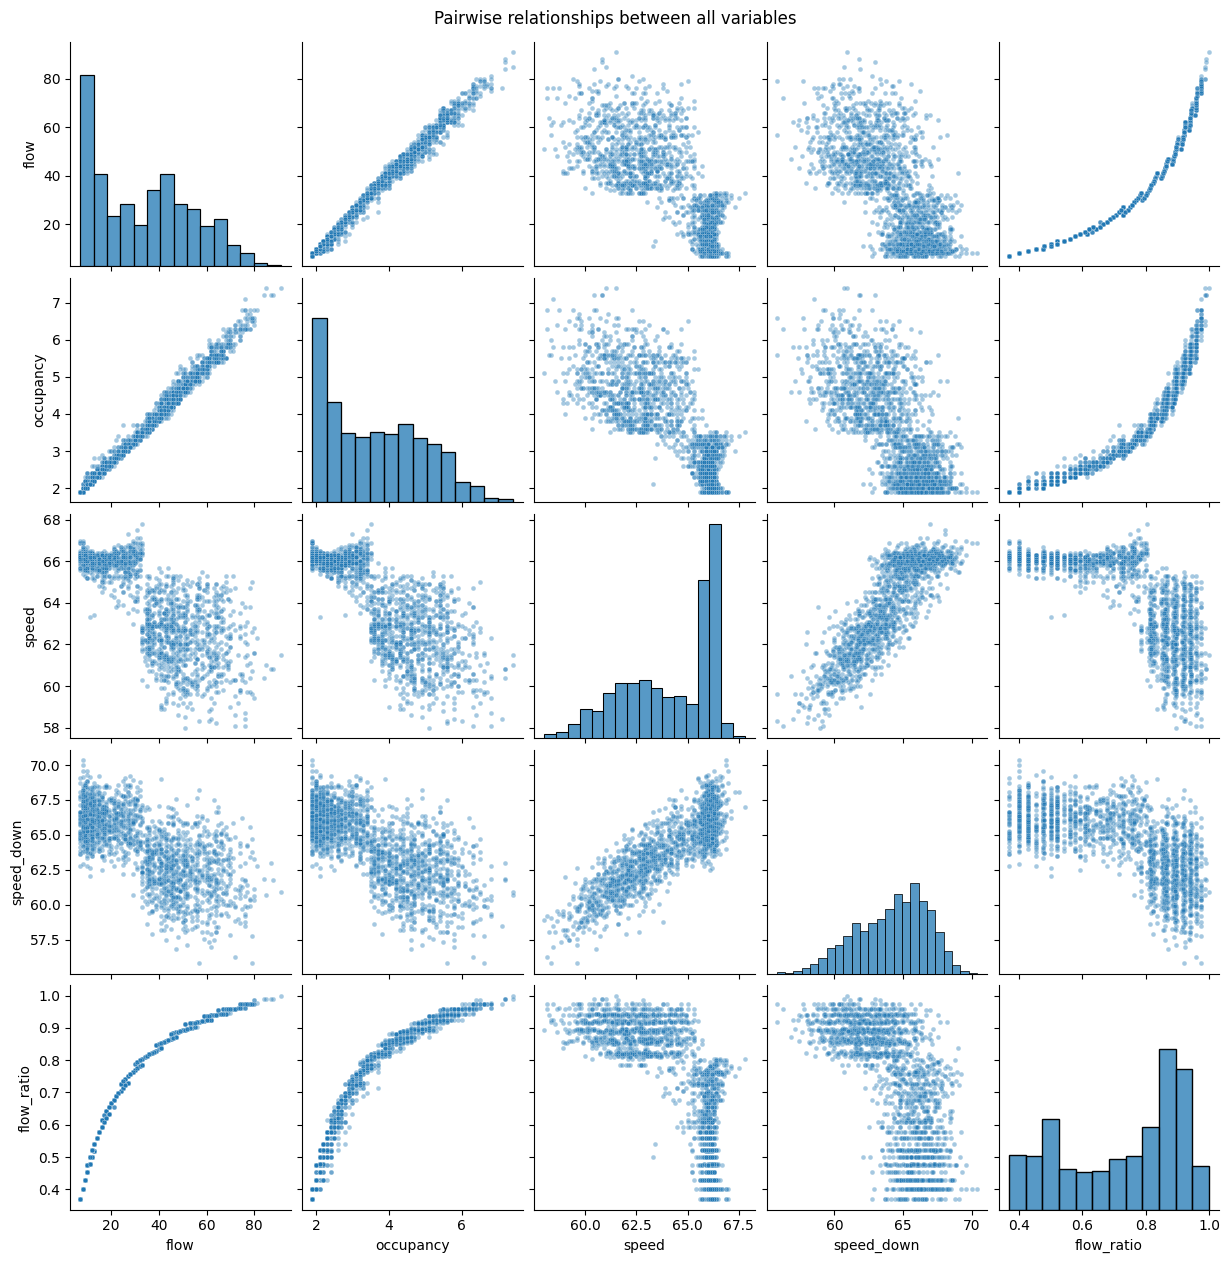

In [13]:
sns.pairplot(df4, plot_kws={'s': 12, 'alpha': 0.4})
plt.suptitle('Pairwise relationships between all variables', y=1.01)
plt.show()

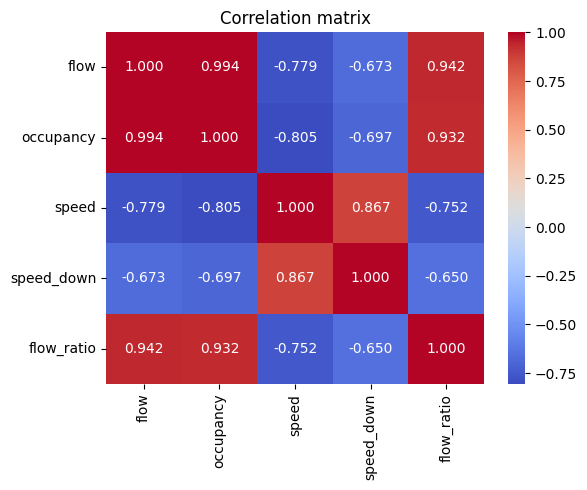

,flow,occupancy,speed,speed_down,flow_ratio
flow,1.00000,0.99389,-0.77862,-0.67300,0.94214
occupancy,0.99389,1.00000,-0.80506,-0.69686,0.93234
speed,-0.77862,-0.80506,1.00000,0.86745,-0.75249
speed_down,-0.67300,-0.69686,0.86745,1.00000,-0.65033
flow_ratio,0.94214,0.93234,-0.75249,-0.65033,1.00000


In [14]:
corr = df4.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()
corr

A few things are clear from these plots:

- `speed` drops as `flow`, `occupancy` and `flow_ratio` go up, and the drop is not a
  straight line - it curves. This is the usual traffic behaviour: speed stays near
  free-flow while the road is empty, then falls once it gets crowded.
- `speed` and `speed_down` move up and down together quite strongly (corr around
  0.87), so the downstream speed should be a useful predictor.
- `flow` and `occupancy` are almost the same thing here (corr 0.994), and
  `flow_ratio` is highly correlated with both. So I already expect multicollinearity.

## 4.2 Fitting the original model and checking multicollinearity

First I fit a plain linear model with all four original predictors, then I compute
the Variance Inflation Factor (VIF). The usual rule is that a VIF above about 5-10
points to a problem. The VIF of the constant column has no real meaning, so I ignore
it.

In [15]:
orig = ['flow', 'occupancy', 'speed_down', 'flow_ratio']
y4 = df4['speed']
X4 = sm.add_constant(df4[orig])

model4 = sm.OLS(y4, X4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  speed   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     2398.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:46:15   Log-Likelihood:                -2321.4
No. Observations:                1816   AIC:                             4653.
Df Residuals:                    1811   BIC:                             4680.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.9687      0.904     43.095      0.0

In [16]:
Xc = sm.add_constant(df4[orig])
vif_table = pd.DataFrame({'variable': Xc.columns})
vif_table['VIF'] = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
vif_table

,variable,VIF
0,const,1961.68748
1,flow,104.23727
2,occupancy,94.88128
3,speed_down,2.09650
4,flow_ratio,9.11658


Yes, there is a clear multicollinearity problem. `flow` and `occupancy` both have
VIFs around 100, far above 10, and `flow_ratio` is also a bit high. The reason is
physical - flow, occupancy and the lane flow ratio all describe how busy the road
is, so they basically carry the same information. That is also why a couple of the
coefficient signs in the summary look strange.

## 4.3 Choosing the variables and transformations

From the plots and the VIF results, my reasoning is:

1. `flow` and `occupancy` measure almost the same thing (corr 0.994), so I keep only
   one and drop the other. I keep `occupancy` because its correlation with `speed` is
   slightly stronger and it is the more direct measure of how congested the lane is.
2. `flow_ratio` is also strongly correlated with flow/occupancy and brings little new
   information, so I drop it too.
3. I keep `speed_down`, since it is a strong and fairly independent predictor of
   `speed`.
4. The pair plots show `speed` bends with `occupancy` and `speed_down` instead of
   going in a straight line, so I add the squared terms `occupancy^2` and
   `speed_down^2` to capture that curve.

So my final set is `occupancy`, `occupancy^2`, `speed_down`, `speed_down^2`.

In [17]:
df4['occupancy_sq']  = df4['occupancy'] ** 2
df4['speed_down_sq']  = df4['speed_down'] ** 2

selected = ['occupancy', 'occupancy_sq', 'speed_down', 'speed_down_sq']
X_sel = sm.add_constant(df4[selected])
model_sel = sm.OLS(y4, X_sel).fit()
print(model_sel.summary())

                            OLS Regression Results                            
Dep. Variable:                  speed   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     2566.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:46:15   Log-Likelihood:                -2269.6
No. Observations:                1816   AIC:                             4549.
Df Residuals:                    1811   BIC:                             4577.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -118.8193     10.682    -11.123

All four terms turn out highly significant (p-values are basically zero), and the
adjusted R-squared (about 0.85) is even a little higher than the original
four-variable model, even though I used fewer variables. So the smaller model with
the squared terms fits better and is easier to explain.

## 4.4 Comparing linear, ridge and lasso

Here I compare three things:

- ordinary linear regression on the variables I selected,
- ridge regression on the original variable set,
- lasso regression on the original variable set.

For ridge and lasso I standardise the variables first (so the coefficients are on
the same scale and can be compared), and I let cross-validation choose the penalty
strength.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score

# (a) Linear regression on the SELECTED variables -> already fitted as model_sel
print('Linear (selected variables): adjusted R2 = {:.4f}'.format(model_sel.rsquared_adj))
print()

# (b) Ridge and Lasso on the ORIGINAL set (standardised)
Xorig  = df4[orig].values
scaler = StandardScaler().fit(Xorig)
Xstd   = scaler.transform(Xorig)

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(Xstd, y4)
lasso = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000).fit(Xstd, y4)

compare = pd.DataFrame({
    'Ridge_coef': ridge.coef_,
    'Lasso_coef': lasso.coef_
}, index=orig)
print(compare.round(4))
print()
print('Ridge: alpha = {:.4f}, R2 = {:.4f}'.format(ridge.alpha_, r2_score(y4, ridge.predict(Xstd))))
print('Lasso: alpha = {:.4f}, R2 = {:.4f}'.format(lasso.alpha_, r2_score(y4, lasso.predict(Xstd))))

Linear (selected variables): adjusted R2 = 0.8497

            Ridge_coef  Lasso_coef
flow           2.26470     2.06880
occupancy     -2.88650    -2.70880
speed_down     1.21220     1.21910
flow_ratio    -0.29470    -0.27040

Ridge: alpha = 0.0518, R2 = 0.8412
Lasso: alpha = 0.0010, R2 = 0.8411


All three end up with a very similar fit (R-squared roughly 0.84-0.85), so they
agree on how much of the speed can be explained.

In the standardised ridge and lasso coefficients, `occupancy` gets the largest
weight and `speed_down` the next, while `flow_ratio` gets the smallest. `flow` still
keeps a coefficient only because it is almost a copy of `occupancy` - the penalty
just splits the shared effect between the two, so together they act as one
"congestion" factor.

This lines up with what I did in 4.3: the two pieces of information that matter are
the congestion level (occupancy, with flow as its duplicate) and the downstream
speed, while `flow_ratio` is the least useful. So ridge and lasso back up my selected
model, which reaches the same predictive power with fewer, easier-to-read variables
plus the squared terms for the curved shape.